In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Define the directory you want to search in
directory = Path(
    "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\coe_dataframes\\coe_results\\multivariate_hawkes\\"
)
files = [
    file for file in directory.rglob("*") if file.is_file() and "times" not in file.name
]

In [23]:
def same_sign(a, b):
    return (a >= 0 and b >= 0) or (a < 0 and b < 0)


dfs = []
for file in files:
    fileparts = file.parts
    method = fileparts[-5]
    pair = fileparts[-4]
    param = fileparts[-3]
    bi_level = fileparts[-2]
    filename = fileparts[-1]

    prediction_df = pd.read_csv(file, sep="\t")
    real_df = pd.read_csv(
        f"C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\coe_dataframes\\simulation_dataframes\\{method}\\{pair}\\{param}\\120\\{bi_level}\\{filename}",
        sep="\t",
    )
    comparison_df = real_df.merge(prediction_df, left_on="real", right_on="time")
    comparison_df = comparison_df.dropna()

    comparison_df["Correct Prediction"] = comparison_df[
        ["predicted_return", "Return"]
    ].apply(lambda x: same_sign(x["predicted_return"], x["Return"]), axis=1)

    df = comparison_df.copy()
    df["method"] = method
    df["pair"] = pair
    df["param"] = param
    df["bi_level"] = bi_level
    df["file"] = filename

    dfs.append(df)

df_coe = pd.concat(dfs)
df_coe = df_coe[df_coe["bi_level"] == "bi_level_5"]
df_coe = df_coe.rename(columns={"real": "Time", "predicted_return": "predicted_return"})
df_coe.head()

,Time,predicted,BaseImbalance,Return,time,predicted_return,Correct Prediction,method,pair,param,bi_level,file
0,25.457,25.536094,0.238095,-0.000047,25.457,-0.000024,1.0,multivariate_hawkes,BTC_USD,training_time_1500,bi_level_5,orderbook_changes_1705356920082_1705353321.tsv
1,26.529,26.381732,0.300000,-0.000082,26.529,-0.000031,1.0,multivariate_hawkes,BTC_USD,training_time_1500,bi_level_5,orderbook_changes_1705356920082_1705353321.tsv
2,28.089,27.611193,0.157895,-0.000070,28.089,-0.000016,1.0,multivariate_hawkes,BTC_USD,training_time_1500,bi_level_5,orderbook_changes_1705356920082_1705353321.tsv
3,30.523,29.422784,0.066667,0.000012,30.523,-0.000007,0.0,multivariate_hawkes,BTC_USD,training_time_1500,bi_level_5,orderbook_changes_1705356920082_1705353321.tsv
4,31.838,31.661702,-0.125000,0.000035,31.838,0.000013,1.0,multivariate_hawkes,BTC_USD,training_time_1500,bi_level_5,orderbook_changes_1705356920082_1705353321.tsv


In [24]:
dfs = []

for pair in ["BTC_USD", "ETH_USD", "ETH_BTC", "BTC_USDT", "ETH_USDT"]:
    directory = Path(f"C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\simulations_multivariate\\multivariate_hawkes\\{pair}\\training_time_1500\\simulation_seconds_120")
    files = [
        file for file in directory.rglob("*") if file.is_file() and "times" not in file.name
    ]

    for file in files:
        df = pd.read_csv(file, sep="\t")
        df["file"] = file
        df["pair"] = pair
        dfs.append(df)

df_hawkes = pd.concat(dfs)
df_hawkes["Predicted Event Type"] = df_hawkes[
    ["Predicted MP UP Time", "Predicted MP DOWN Time"]
].apply(
    lambda x: (
        "MID_PRICE_UP"
        if x["Predicted MP UP Time"] < x["Predicted MP DOWN Time"]
        else "MID_PRICE_DOWN"
    ),
    axis=1,
)
df_hawkes["Correct Prediction"] = df_hawkes["Predicted Event Type"] == df_hawkes["Real Event Type"]
df_hawkes = df_hawkes.rename(columns={"Real Event Time": "Time"})
df_hawkes.head()

,Time,Real Event Type,Predicted MP UP Time,Predicted MP DOWN Time,Real Time Previous Event,Real Type Previous Event,Return,file,pair,Predicted Event Type,Correct Prediction
0,151.150,MID_PRICE_UP,162.534880,151.467877,150.678,MID_PRICE_DOWN,0.000023,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_DOWN,False
1,151.382,MID_PRICE_UP,163.186839,157.599259,151.150,SELL_PRESSURE_UP,-0.000012,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_DOWN,False
2,151.616,MID_PRICE_DOWN,151.850567,157.209817,151.150,MID_PRICE_UP,0.000023,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_UP,False
3,152.026,MID_PRICE_UP,152.426964,157.607665,151.617,MID_PRICE_UP,-0.000012,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_UP,True
4,152.514,MID_PRICE_DOWN,156.113129,154.890946,152.291,SELL_PRESSURE_UP,-0.000047,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_DOWN,True


In [25]:
df_hawkes.iloc[0,:]['file']

WindowsPath('C:/Users/Admin/OneDrive - Politecnico di Milano/phd/code/multivariate_hawkes/data/simulations_multivariate/multivariate_hawkes/BTC_USD/training_time_1500/simulation_seconds_120/orderbook_changes_1705356920082_1705353321.tsv')

In [26]:
df_hawkes[df_hawkes['file'] == df_hawkes.iloc[0,:]['file']]

,Time,Real Event Type,Predicted MP UP Time,Predicted MP DOWN Time,Real Time Previous Event,Real Type Previous Event,Return,file,pair,Predicted Event Type,Correct Prediction
0,151.150,MID_PRICE_UP,162.534880,151.467877,150.678,MID_PRICE_DOWN,0.000023,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_DOWN,False
1,151.382,MID_PRICE_UP,163.186839,157.599259,151.150,SELL_PRESSURE_UP,-0.000012,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_DOWN,False
2,151.616,MID_PRICE_DOWN,151.850567,157.209817,151.150,MID_PRICE_UP,0.000023,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_UP,False
3,152.026,MID_PRICE_UP,152.426964,157.607665,151.617,MID_PRICE_UP,-0.000012,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_UP,True
4,152.514,MID_PRICE_DOWN,156.113129,154.890946,152.291,SELL_PRESSURE_UP,-0.000047,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_DOWN,True
5,153.890,MID_PRICE_UP,163.113168,158.041723,153.181,SELL_PRESSURE_UP,0.000012,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_DOWN,False
6,157.799,MID_PRICE_UP,167.441092,162.615376,157.352,BUY_PRESSURE_UP,0.000012,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_DOWN,False
7,159.698,MID_PRICE_UP,168.950279,164.228491,158.913,MID_PRICE_UP,0.000082,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_DOWN,False
8,160.456,MID_PRICE_UP,170.157215,160.647232,159.937,MID_PRICE_UP,0.000035,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_DOWN,False
9,160.703,MID_PRICE_UP,170.464244,165.579565,160.456,MID_PRICE_UP,-0.000023,C:\Users\Admin\OneDrive - Politecnico di Milan...,BTC_USD,MID_PRICE_DOWN,False


In [ ]:
def trading_simulation(df):
    initial_capital = 1000
    records = []
    
    for file in df['file'].unique():
        for pair in df['pair'].unique():
            capital = initial_capital
            df_subset = df[(df['file'] == file) & (df['pair'] == pair)].sort_values(by='Time')
        
            for _, row in df_subset.iterrows():
                if row['Correct Prediction']:
                    capital *= (1 + abs(row['Return']))  # Increase capital
                else:
                    capital *= (1 - abs(row['Return']))  # Decrease capital
                
                records.append({'Time': row['Time'], 'Capital': capital, 'File': file, 'Pair': pair})
        
    return pd.DataFrame(records)



In [37]:
def trading_simulation(df):
    initial_capital = 1000
    records = []
    
    for file in df['file'].unique():
        for pair in df['pair'].unique():
            capital = initial_capital
            df_subset = df[(df['file'] == file) & (df['pair'] == pair)].sort_values(by='Time')
            
            if df_subset.empty:
                continue

            records.append({'Time': 0, 'Capital': initial_capital, 'File': file, 'Pair': pair})  # Force same start
            
            start_time = df_subset['Time'].min()
            df_subset['Time'] = df_subset['Time'] - start_time  # Normalize start times
            
            for _, row in df_subset.iterrows():
                if row['Correct Prediction']:
                    capital *= (1 + abs(row['Return']))  # Increase capital
                else:
                    capital *= (1 - abs(row['Return']))  # Decrease capital
                
                records.append({'Time': row['Time'], 'Capital': capital, 'File': file, 'Pair': pair})
    
    return pd.DataFrame(records)

trading_simulation_coe_df = trading_simulation(df_coe)
trading_simulation_hawkes = trading_simulation(df_hawkes)

def plot_capital_evolution(df, pair):
    df_pair = df[df['Pair'] == pair]
    
    # Resample times to a common grid using interpolation
    common_times = sorted(df_pair['Time'].unique())
    df_interpolated = df_pair.pivot_table(index='Time', columns='File', values='Capital').reindex(common_times).interpolate()
    
    df_mean = df_interpolated.mean(axis=1)
    df_std = df_interpolated.std(axis=1)
    
    plt.figure(figsize=(10, 5))
    sns.lineplot(x=common_times, y=df_mean, label='Mean Capital')
    plt.fill_between(common_times, df_mean - df_std, df_mean + df_std, alpha=0.3, label='Std Dev')
    plt.xlabel('Time')
    plt.ylabel('Capital')
    plt.title(f'Capital Evolution for Pair: {pair}')
    plt.legend()
    plt.show()

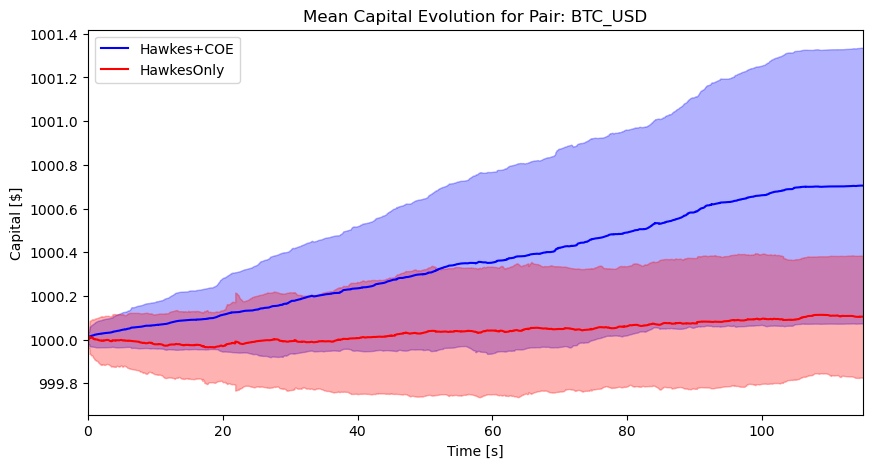

In [41]:
def plot_capital_evolution(df1, df2, pair, label1='Dataset 1', label2='Dataset 2'):
    df1_pair = df1[df1['Pair'] == pair]
    df2_pair = df2[df2['Pair'] == pair]
    
    # Resample times to a common grid using interpolation
    common_times = sorted(set(df1_pair['Time'].unique()) | set(df2_pair['Time'].unique()))
    
    df1_interpolated = df1_pair.pivot_table(index='Time', columns='File', values='Capital').reindex(common_times).interpolate()
    df2_interpolated = df2_pair.pivot_table(index='Time', columns='File', values='Capital').reindex(common_times).interpolate()
    
    df1_mean = df1_interpolated.mean(axis=1)
    df1_std = df1_interpolated.std(axis=1)
    df2_mean = df2_interpolated.mean(axis=1)
    df2_std = df2_interpolated.std(axis=1)
    
    plt.figure(figsize=(10, 5))
    sns.lineplot(x=common_times, y=df1_mean, label=label1, color='blue')
    plt.fill_between(common_times, df1_mean - df1_std, df1_mean + df1_std, alpha=0.3, color='blue')
    
    sns.lineplot(x=common_times, y=df2_mean, label=label2, color='red')
    plt.fill_between(common_times, df2_mean - df2_std, df2_mean + df2_std, alpha=0.3, color='red')
    
    plt.xlabel('Time [s]')
    plt.ylabel('Capital [$]')
    plt.title(f'Mean Capital Evolution for Pair: {pair}')
    plt.legend()
    plt.xlim(0, 115)
    plt.show()
    
plot_capital_evolution(trading_simulation_coe_df, trading_simulation_hawkes, 'BTC_USD', 'Hawkes+COE', "HawkesOnly")